# Cell Nuclei Separation: Watershed Algorithm
**Task:** Separate touching nuclei using Marker-controlled watershed.
**Dataset:** Kaggle — Data Science Bowl 2018 (Cell Nuclei)
**Objective:** Compare standard watershed (without explicit markers) vs. Marker-controlled watershed to demonstrate over-segmentation control.

In [1]:
# Import required libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage import color
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'cv2'

## 1. Data Loading and Preprocessing
First, we load a sample image from the dataset, convert it to grayscale, and apply Otsu's thresholding to create a binary mask. In this mask, touching cells will appear as single, merged blobs.

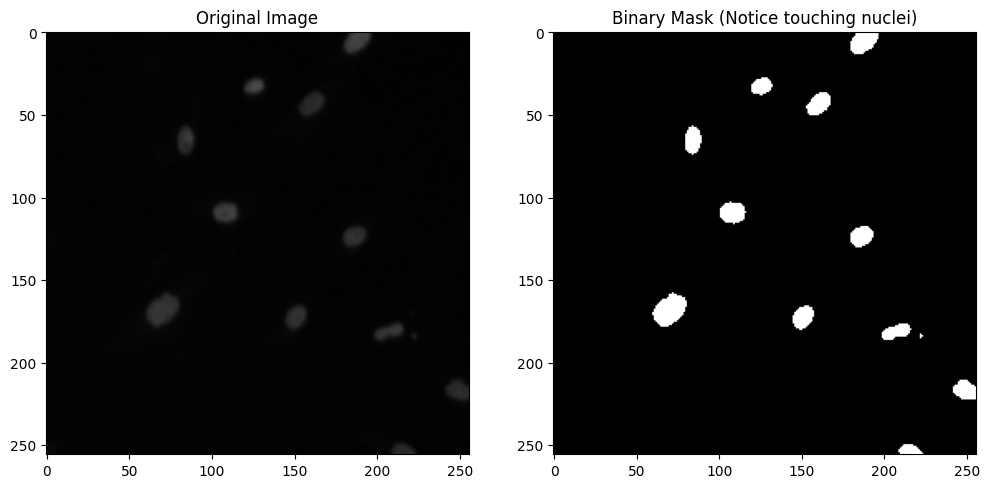

In [2]:
# Define the path to a specific image in your Drive
# Make sure to replace this with an actual Image ID from your folder if this one doesn't exist
BASE_PATH = '/content/drive/MyDrive/DSB2018/stage1_train'
sample_id = os.listdir(BASE_PATH)[0] # Just grabs the first folder
img_path = os.path.join(BASE_PATH, sample_id, 'images', sample_id + '.png')

# Load image and convert to grayscale
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Otsu's thresholding to get the binary mask
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Plotting the original and binary image
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original Image")
ax[1].imshow(thresh, cmap='gray')
ax[1].set_title("Binary Mask (Notice touching nuclei)")
plt.show()

## 2. Distance Transform
To use the watershed algorithm, we treat the image like a topological map. We calculate the distance transform, which assigns higher values to pixels that are further away from the background. The centers of the nuclei will become the "peaks" of our topography.

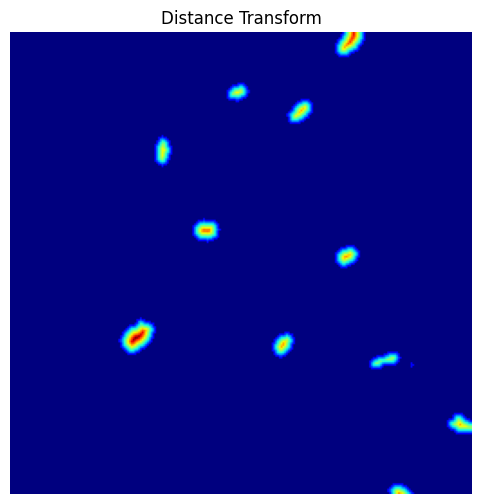

In [3]:
# Calculate the Euclidean distance transform
distance = ndimage.distance_transform_edt(thresh)

plt.figure(figsize=(6,6))
plt.imshow(distance, cmap='jet')
plt.title("Distance Transform")
plt.axis('off')
plt.show()

## 3. Compare: Without Markers vs. With Markers

**Without Markers (Standard Watershed):** If we apply the watershed algorithm directly to the inverse distance transform without specifying robust markers, the algorithm assumes *every* local minimum is a basin. This leads to severe over-segmentation due to noise in the cell shapes.

**Marker-Controlled Watershed:** We find specific, distinct peaks in the distance transform using a minimum distance constraint. We label these peaks and use them as definitive starting markers. The algorithm only floods from these controlled seeds, perfectly separating the touching cells without fracturing them.

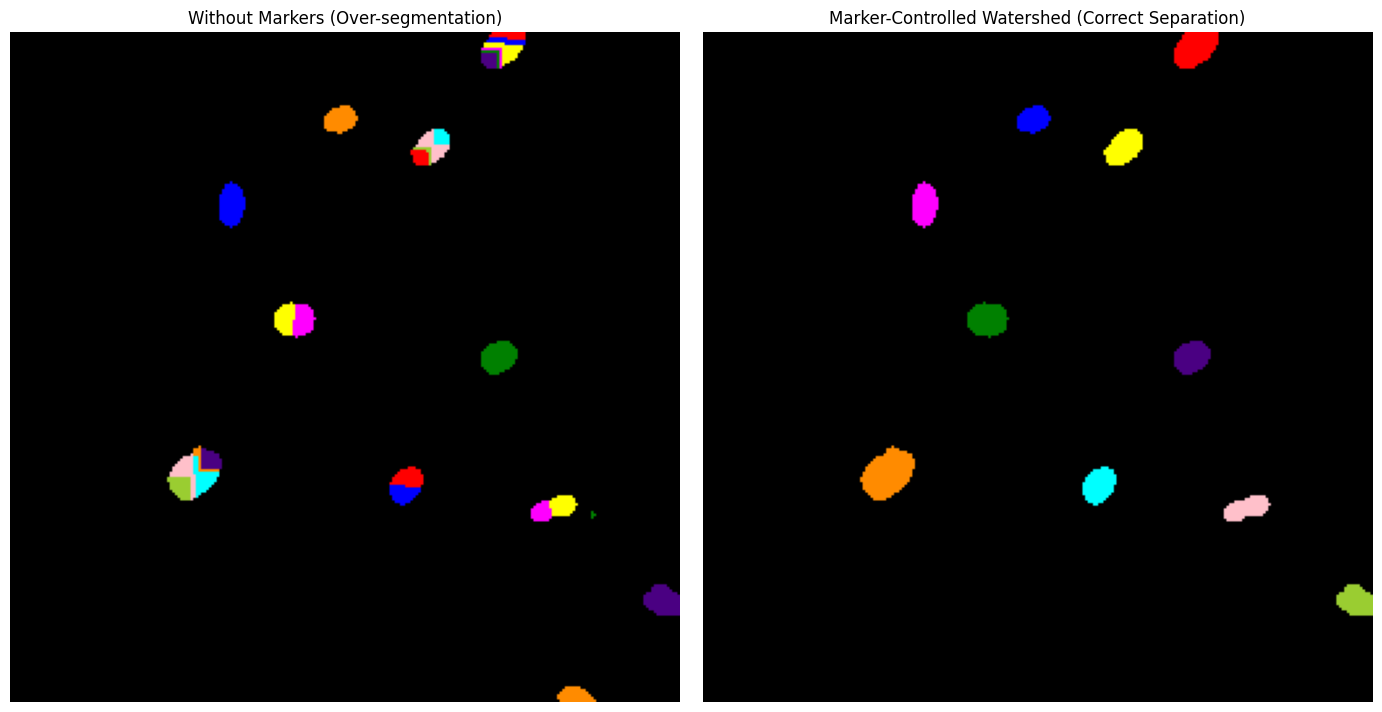

In [4]:
# --- METHOD A: WITHOUT MARKERS (Naïve) ---
# We use the negative distance transform.
# Without explicit markers, skimage watershed finds all local minima automatically.
labels_without_markers = watershed(-distance, mask=thresh)

# --- METHOD B: WITH MARKERS (Marker-Controlled) ---
# 1. Find local peaks in the distance map to act as markers
# min_distance controls sensitivity. Higher = less sensitive (fewer markers)
local_peaks = peak_local_max(distance, min_distance=10, labels=thresh)

# 2. Create a boolean mask of the peaks
peak_mask = np.zeros_like(distance, dtype=bool)
peak_mask[tuple(local_peaks.T)] = True

# 3. Label the markers uniquely
markers, _ = ndimage.label(peak_mask)

# 4. Apply Marker-Controlled Watershed
labels_with_markers = watershed(-distance, markers, mask=thresh)

# --- VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)

# Colorize labels for visualization
colored_without = color.label2rgb(labels_without_markers, bg_label=0)
colored_with = color.label2rgb(labels_with_markers, bg_label=0)

axes[0].imshow(colored_without)
axes[0].set_title("Without Markers (Over-segmentation)")
axes[0].axis('off')

axes[1].imshow(colored_with)
axes[1].set_title("Marker-Controlled Watershed (Correct Separation)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Conclusion & Sensitivity Trade-offs
Conclusion: Over-Segmentation Control and Sensitivity Trade-offs
Implementing the marker-controlled watershed algorithm effectively resolves the inherent over-segmentation problem seen in standard watershed approaches. By utilizing the distance transform alongside local peak detection, we restrict the flooding process to originate only from highly confident cellular centers (markers). However, this introduces a critical sensitivity trade-off controlled by the peak detection parameters (specifically the min_distance threshold). If the threshold is set too low (high sensitivity), minor irregularities in the cell boundaries or chromatin texture generate false peaks, fracturing a single nucleus into multiple segments (over-segmentation). Conversely, if the threshold is set too high (low sensitivity), the algorithm fails to generate distinct markers for tightly clustered or overlapping nuclei, causing under-segmentation where multiple distinct cells are falsely merged into one. Optimizing this parameter requires balancing the morphological variance of the dataset against the density of the cell clusters.